# ClimaSentAR

In [ ]:
import pandas as pd
clim = pd.read_excel('ClimaSentAR Dataset.xlsx')

clim.drop_duplicates(subset='text', inplace = True)
clim.dropna(inplace = True, subset='text')
clim.reset_index(drop=True, inplace = True)

print(clim['sentiment'].value_counts())

sentiment
Neutral     10307
Negative     8140
Positive     5510
Name: count, dtype: int64


In [ ]:
clim.shape[0]

23957

## Class Distribution

In [ ]:
print(f'''    Neutral(%)          Negative(%)        Positive(%)
{10307*100/23957, 8140*100/23957, 5510*100/23957}''')

    Neutral(%)          Negative(%)        Positive(%)
(43.02291605793714, 33.977543098050674, 22.999540844012188)


# Hashtags Plot

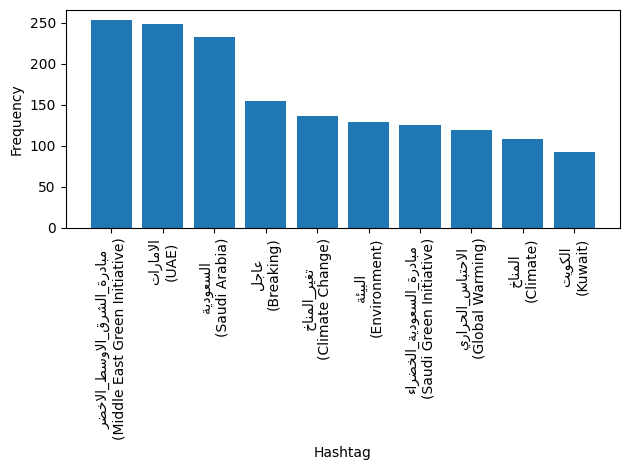

In [ ]:
translations = {
    "مبادرة_الشرق_الاوسط_الاخضر": "Middle East Green Initiative",
    "الامارات": "UAE",
    "السعودية": "Saudi Arabia",
    "عاجل": "Breaking",
    "تغير_المناخ": "Climate Change",
    "البيئة": "Environment",
    "مبادرة_السعودية_الخضراء": "Saudi Green Initiative",
    "الاحتباس_الحراري": "Global Warming",
    "المناخ": "Climate",
    "الكويت": "Kuwait"
}


import arabic_reshaper
from bidi.algorithm import get_display

all_hashtags = clim['text'].str.extractall(r'#(\w+)')[0]
top_hashtags = all_hashtags.value_counts().head(10)

reshaped_labels = []
for label in top_hashtags.index:
    arabic = get_display(arabic_reshaper.reshape(label))
    english = translations.get(label, "N/A")
    reshaped_labels.append(f"{arabic}\n({english})")

plt.bar(reshaped_labels, top_hashtags.values)
plt.xlabel("Hashtag")
plt.ylabel("Frequency")
plt.xticks(
    ticks=range(len(reshaped_labels)),
    labels=reshaped_labels,
    rotation=90,
    ha='center',
    multialignment='center'
)

plt.tight_layout()
plt.show()


## Total URLs

In [ ]:
import re

# Regex pattern for URLs (matches http/https followed by non-whitespace)
# A more comprehensive regex might be needed for complex URL formats
URL_PATTERN = r'https?://\S+'

# Count the number of URLs in the 'text_column' for each row
clim['url_count'] = clim['text'].str.findall(URL_PATTERN).str.len()

# To get the total number of URLs across the entire DataFrame column
total_urls = clim['url_count'].sum()
print(f"\nTotal URLs found in the column: {total_urls}")



Total URLs found in the column: 430


## Total Emojis and Emoji Instances

In [ ]:
!pip install -q emoji

In [ ]:
import emoji

# Boolean mask: True if a row contains at least one emoji
has_emoji = clim['text'].apply(lambda x: len(emoji.emoji_list(str(x))) > 0)

# Count how many rows contain at least one emoji
num_samples_with_emoji = has_emoji.sum()

print(num_samples_with_emoji)

2992


In [ ]:
clim['has_emoji'] = has_emoji.values
clim[clim['has_emoji'] == True]['sentiment'].value_counts()

,count
sentiment,
Neutral,1090
Negative,1030
Positive,872


In [ ]:
# Count total number of emojis across all rows
total_emojis = clim['text'].apply(lambda x: len(emoji.emoji_list(str(x)))).sum()

print(total_emojis)

6111


## Non-ASCII Characters

In [ ]:
import emoji
import unicodedata

def normalize_text(text):
    text = str(text)

    # Normalize presentation forms → standard Arabic letters
    text = unicodedata.normalize('NFKC', text)

    return text

clim['text'] = clim['text'].apply(normalize_text)

def is_arabic(char):
    return (
        '\u0600' <= char <= '\u06FF' or
        '\u0750' <= char <= '\u077F' or
        '\u08A0' <= char <= '\u08FF' or
        '\uFB50' <= char <= '\uFDFF' or
        '\uFE70' <= char <= '\uFEFF'
    )

def extract_unwanted_non_ascii(text):
    text = str(text)

    chars = []
    for ch in text:
        if (
            ord(ch) > 127 and           # Non-ASCII
            not is_arabic(ch) and          # Not Arabic
            not emoji.is_emoji(ch)
        ):
            chars.append(ch)

    return chars


all_chars = clim['text'].apply(extract_unwanted_non_ascii)

# Flatten list of lists
flattened = [ch for sublist in all_chars for ch in sublist]

# Count
total_count = len(flattened)

print("Total non-ASCII characters (excluding Arabic & emojis):", total_count)

unique_chars = list(set(flattened))

print("Sample characters:", unique_chars[:20])

from collections import Counter

counter = Counter(flattened)
print("Most common:", counter.most_common(20))

Total non-ASCII characters (excluding Arabic & emojis): 3349
Sample characters: ['ь', '×', '»', '🇳', 'ô', '£', '♧', '🇯', 'ä', '❍', '︎', '『', '⠀', 'à', '》', '𓃵', '́', '🇬', '🇶', 'и']
Most common: [('️', 934), ('•', 214), ('🇦', 205), ('”', 186), ('“', 176), ('»', 164), ('«', 155), ('🇪', 154), ('🇸', 129), ('°', 70), ('–', 66), ('⃣', 63), ('🇺', 46), ('🇩', 39), ('🇷', 38), ('—', 35), ('🇳', 35), ('🇰', 32), ('🇮', 32), ('🇾', 30)]


In [ ]:
# Boolean mask: True if a row contains at least one unwanted non-ASCII char
mask_rows_with_unwanted = all_chars.apply(lambda x: len(x) > 0)

# Count rows
num_rows_with_unwanted = mask_rows_with_unwanted.sum()

print("Number of rows containing at least one unwanted character:", num_rows_with_unwanted)

Number of rows containing at least one unwanted character: 1507


In [ ]:
total_instances = all_chars.apply(len).sum()

print("Total unwanted character instances:", total_instances)

Total unwanted character instances: 3349


## Usernames

In [ ]:
import re

# Pattern for hashtags (words starting with #)
USERNAME_PATTERN = r'@\w+'

# Count hashtags in each row and sum
total_usernames = clim['text'].astype(str).str.count(USERNAME_PATTERN).sum()

print("Total usernames in the column:", total_usernames)

Total usernames in the column: 1200


In [ ]:
import re

# Pattern for hashtags
USERNAME_PATTERN = r'@\w+'

# Boolean mask: True if row contains at least one hashtag
mask_with_usernames = clim['text'].astype(str).str.contains(USERNAME_PATTERN)

# Count rows
num_rows_with_username = mask_with_usernames.sum()

print("Number of rows containing at least one username:", num_rows_with_username)

Number of rows containing at least one username: 859


## Count Diacritics

In [ ]:
import pandas as pd
import re

# Define the regex pattern for Arabic diacritics
# These are the common Tashkil (vowel marks) and other diacritics in the Arabic Unicode block (U+0600–U+06FF)
DIACRITICS_PATTERN = re.compile(
    r'[\u064B-\u0652\u0610-\u061A\u0654-\u065F\u06D6-\u06DC'
    r'\u06DF-\u06E4\u06E7-\u06E8\u06EA-\u06ED\u08D4-\u08FF]'
)

def has_diacritics(text):
    """Checks if a given string contains any Arabic diacritics."""
    if isinstance(text, str):
        return bool(DIACRITICS_PATTERN.search(text))
    return False

# 1. Create a boolean mask indicating rows with diacritics
mask_with_diacritics = clim['text'].apply(has_diacritics)

# 2. Count the number of True values in the mask
count_with_diacritics = mask_with_diacritics.sum()

# 3. Print the result
print(f"Total rows with Arabic text: {len(clim)}")
print(f"Number of texts with diacritics: {count_with_diacritics}")

Total rows with Arabic text: 23957
Number of texts with diacritics: 4798


In [ ]:
def count_words_with_diacritics(text):
    if not isinstance(text, str):
        return 0

    words = text.split()

    # Count words that contain at least one diacritic
    return sum(1 for word in words if DIACRITICS_PATTERN.search(word))


# Apply to entire column
total_words_with_diacritics = clim['text'].apply(count_words_with_diacritics).sum()

print("Total words with diacritics:", total_words_with_diacritics)

Total words with diacritics: 9655


In [ ]:
def extract_words_with_diacritics(text):
    if not isinstance(text, str):
        return []

    words = text.split()
    return [word for word in words if DIACRITICS_PATTERN.search(word)]


# Collect examples
examples = clim['text'].apply(extract_words_with_diacritics)

# Flatten
flattened_words = [w for sublist in examples for w in sublist]

print("Sample words:", list(set(flattened_words))[:20])

Sample words: ['تخويفاً', 'شرقِ', 'أَطْفَأَهَا', 'تُغرق', '«معاً', '#شكراً_مدارس_رياض_الحياة', 'حُجرة-', 'بالتحوّل', 'فعالاً', 'حسبَ', 'شركةًالمياه', 'يُتيح', 'رَبِّهِمْ', 'برنامجًا', 'إنّه', 'النيّة', 'حيناً', 'بُكره', 'يُسعدنا', 'فيبلغُ']


## Redundant Punctuations

In [ ]:
import pandas as pd
import re

redundant_punct_pattern = r'([،؟.\!])\1+'

# Find rows
rows_with_redundant = clim[clim['text'].str.contains(redundant_punct_pattern, regex=True, na=False)]

# Count of rows
count = len(rows_with_redundant)
print(f"Number of rows with redundant punctuation: {count}")

Number of rows with redundant punctuation: 4682


/tmp/ipython-input-2839633822.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  rows_with_redundant = clim[clim['text'].str.contains(redundant_punct_pattern, regex=True, na=False)]


In [ ]:
import re

pattern = r'([،؟.!])\1+'

def count_redundant_instances(text):
    text = str(text)
    matches = re.findall(pattern, text)
    return sum(len(m.group(0)) for m in re.finditer(pattern, text))

total_redundant_instances = clim['text'].apply(count_redundant_instances).sum()

print("Total redundant punctuation instances:", total_redundant_instances)

Total redundant punctuation instances: 7044


## Line breaks/tab/and extra white spaces

In [ ]:
# Pattern for extra whitespace
EXTRA_WHITESPACE_PATTERN = re.compile(r'\s{2,}|\t|\n')

# Boolean mask
mask_extra_ws = clim['text'].astype(str).str.contains(EXTRA_WHITESPACE_PATTERN)

# Count rows
count_extra_ws = mask_extra_ws.sum()

print("Number of texts with extra line breaks/tab/whitespaces:", count_extra_ws)

Number of texts with extra line breaks/tab/whitespaces: 6716


In [ ]:
def count_extra_whitespace(text):
    text = str(text)
    return len(EXTRA_WHITESPACE_PATTERN.findall(text))

total_extra_whitespace = clim['text'].apply(count_extra_whitespace).sum()

print("Total extra line breaks/tab/whitespaces occurrences:", total_extra_whitespace)

Total extra line breaks/tab/whitespaces occurrences: 11485


## Hashtags

In [ ]:
import re

# Pattern for hashtags (words starting with #)
HASHTAG_PATTERN = r'#\w+'

# Count hashtags in each row and sum
total_hashtags = clim['text'].astype(str).str.count(HASHTAG_PATTERN).sum()

print("Total hashtags in the column:", total_hashtags)

Total hashtags in the column: 16610


In [ ]:
import re

# Pattern for hashtags
HASHTAG_PATTERN = r'#\w+'

# Boolean mask: True if row contains at least one hashtag
mask_with_hashtag = clim['text'].astype(str).str.contains(HASHTAG_PATTERN)

# Count rows
num_rows_with_hashtag = mask_with_hashtag.sum()

print("Number of rows containing at least one hashtag:", num_rows_with_hashtag)

Number of rows containing at least one hashtag: 8956


## Token Length

In [ ]:
!pip install -q transformers==4.49.0
!pip install -q PyArabic
!pip install -q arabert

In [ ]:
import string
import pyarabic.araby as araby
import re

clim['text'] = clim['text'].str.replace(r'[^\w\s]+', '')
clim['text'] = clim['text'].str.replace("\s+", " ", regex=True)

arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("گ", "ك", text)
    return text

def remove_repeating_char(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

clim['text'] = clim['text'].apply(normalize_arabic)
clim['text'] = clim['text'].apply(remove_repeating_char)

def data_cleaning(text):
    """Clean and preprocess text data.
    Args:
        text (pd.Series): A pandas Series containing text data to be cleaned.
    Returns:
        pd.Series: A pandas Series with the cleaned text data.

    Cleaning Steps:
    - Removes emojis and special characters like '\x89Û_', '&amp', etc.
    - Replaces consecutive dots with an empty string.
    - Removes '#' symbol from text.
    - Removes user names starting with '@'.
    - Removes URLs starting with 'http' or 'https'.
    - Remove diacritics.
    - Remove English.
    - Removes extra whitespaces between words.

    """
    clean = text
    # Replace consecutive dots with an empty string
    pattern = re.compile('\\.+?(?=\B|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Replace '\x89Û_' with a whitespace
    pattern = re.compile('\x89Û_')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Replace newline characters with a whitespace
    pattern = re.compile('\\n')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Remove '#' symbol from text
    clean = clean.apply(lambda r: r.replace('#', ''))
    # Remove '_' symbol from text
    pattern = re.compile('_')
    clean = clean.apply(lambda r: re.sub(pattern, ' ', r))
    # Replace user names with '@'
    pattern = re.compile('@[a-zA-Z0-9\_]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='@'))
    # Remove URLs
    pattern = re.compile('https?\S+(?=\s|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='www'))
    # Remove emojis
    # clean = clean.apply(lambda r: emoji.replace_emoji(r, replace=""))
    # Remove diacritics
    clean = clean.apply(lambda r: araby.strip_diacritics(r))
    # Remove English
    pattern = re.compile(r'[a-zA-Z]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Remove extra whitespaces
    clean = clean.apply(lambda r: ' '.join(r.split()))  # Remove extra whitespaces between words

    return clean

clim['text'] = data_cleaning(clim['text'])

def remove_specific_term(text):
  cleaned_text = re.sub(r'\bpictwitercom\w*\b', '', text)
  cleaned_text = cleaned_text.strip() # Remove any leading or trailing whitespace
  return cleaned_text

clim['text'] = clim['text'].apply(remove_specific_term)

def remove_ids(text):
  return text.split("—")[0].strip()

clim['text'] = clim['text'].apply(remove_ids)

In [ ]:
!pip install emoji==1.6.3

In [ ]:
from arabert.preprocess import ArabertPreprocessor
arabic_prep = ArabertPreprocessor('aubmindlab/bert-base-arabertv02-twitter')

clim['text'] = clim['text'].apply(lambda x: arabic_prep.preprocess(x))

In [ ]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained('aubmindlab/bert-base-arabertv02-twitter')

# Maximum token length for training set
text_lengths = [len(tok.tokenize(sentence)) for sentence in clim['text'].to_list()]
max_text_length = max(text_lengths)
print("Maximum token length in training set:", max_text_length)

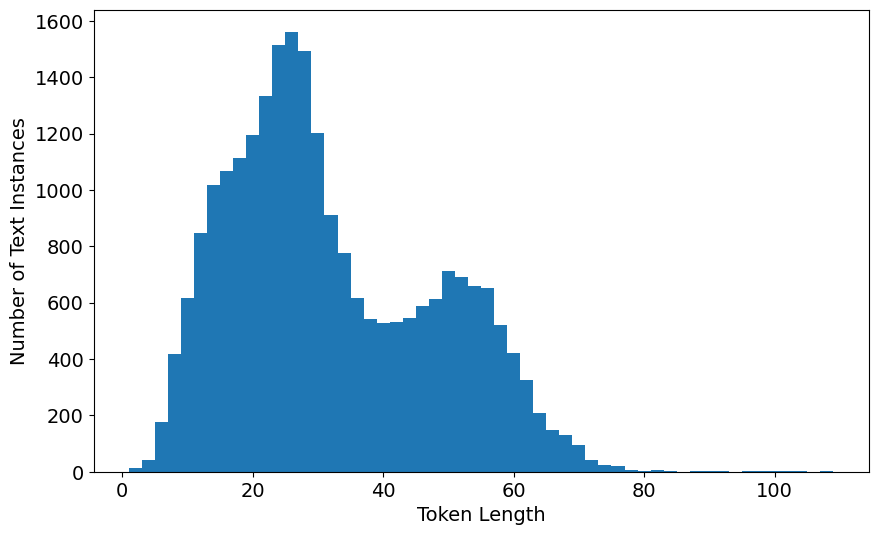

In [ ]:
import matplotlib.pyplot as plt

token_lengths = [len(tok.tokenize(sentence)) for sentence in clim['text'].to_list()]

plt.rcParams.update({'font.size': 14})  # increase base font size
plt.figure(figsize=(10,6))
plt.hist(token_lengths, bins=range(1, 110, 2))
plt.xlabel("Token Length")
plt.ylabel("Number of Text Instances")

plt.savefig("token_length_histogram.png", dpi=300, bbox_inches='tight')

plt.show()